In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier

import numpy as np


warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid') 
sns.set_palette('Set2')

In [2]:
df = pd.read_csv('car_price.csv')

print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [35]:
rows, cols = df.shape
print(f'Dataset Shape: {df.shape}')
print(f' - Number of Rows    : {rows:,}')
print(f' - Number of Columns : {cols}')
print(f'\n Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f'   {i:2}. {col}')

Dataset Shape: (72435, 10)
 - Number of Rows    : 72,435
 - Number of Columns : 10

 Column Names:
    1. model
    2. year
    3. price
    4. transmission
    5. mileage
    6. fuelType
    7. tax
    8. mpg
    9. engineSize
   10. Make


In [3]:
print('Data Types of Each Column:')
print(df.dtypes)
print()

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f' - Numerical Features ({len(numerical_cols)})  : {numerical_cols}')
print(f' - Categorical Features ({len(categorical_cols)}): {categorical_cols}')

Data Types of Each Column:
model               str
year            float64
price           float64
transmission        str
mileage         float64
fuelType            str
tax             float64
mpg             float64
engineSize      float64
Make                str
dtype: object

 - Numerical Features (6)  : ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
 - Categorical Features (4): ['model', 'transmission', 'fuelType', 'Make']


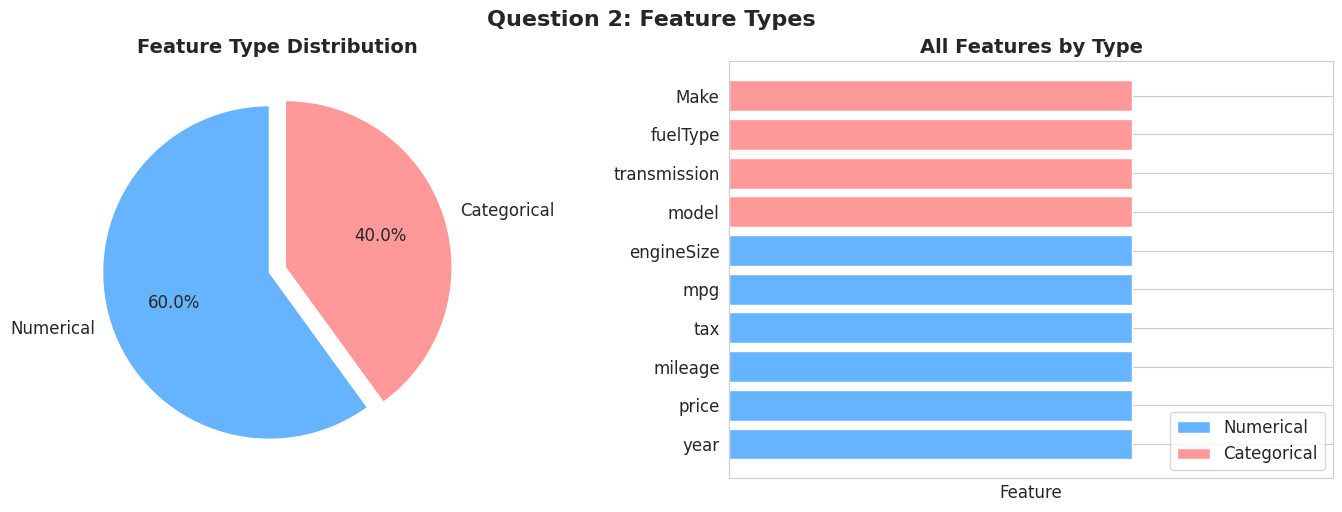

In [37]:
# Visualize feature types
type_counts = {'Numerical': len(numerical_cols), 'Categorical': len(categorical_cols)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(type_counts.values(), labels=type_counts.keys(),
            autopct='%1.1f%%', startangle=90,
            colors=['#66b3ff', '#ff9999'], explode=(0.05, 0.05))
axes[0].set_title('Feature Type Distribution', fontsize=14, fontweight='bold')

# Bar chart with column names
all_cols = [(col, 'Numerical') for col in numerical_cols] + [(col, 'Categorical') for col in categorical_cols]
col_names = [c[0] for c in all_cols]
col_colors = ['#66b3ff' if c[1] == 'Numerical' else '#ff9999' for c in all_cols]
axes[1].barh(col_names, [1]*len(col_names), color=col_colors)
axes[1].set_xlabel('Feature')
axes[1].set_title('All Features by Type', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#66b3ff', label='Numerical'),
                   Patch(facecolor='#ff9999', label='Categorical')]
axes[1].legend(handles=legend_elements, loc='lower right')
axes[1].set_xticks([])

plt.tight_layout()
plt.suptitle('Question 2: Feature Types', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [38]:
print('Statistical Summary of Numerical Features:')
df[numerical_cols].describe().round(2)

Statistical Summary of Numerical Features:


,year,price,mileage,tax,mpg,engineSize
count,68813.00,68814.00,68813.00,68814.00,68814.00,68813.00
mean,2017.08,16583.92,23179.44,116.93,55.84,1.64
std,2.10,9304.41,21347.57,64.08,17.04,0.56
min,1996.00,495.00,1.00,0.00,0.30,0.00
25%,2016.00,10167.25,7199.00,30.00,47.90,1.20
50%,2017.00,14495.00,17521.00,145.00,55.40,1.60
75%,2019.00,20359.75,32478.00,145.00,62.80,2.00
max,2020.00,145000.00,323000.00,580.00,470.80,6.60


In [39]:
print('Unique Values in Categorical Features:')
for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    print(f'\n  [{col}] — {len(unique_vals)} unique values:')
    print(f'{list(unique_vals[:])}')

Unique Values in Categorical Features:

  [model] — 145 unique values:
[' A1', ' A6', ' A4', ' A3', ' Q3', ' Q5', ' A5', ' S4', ' Q2', ' A7', ' TT', ' Q7', ' RS6', ' RS3', ' A8', ' Q8', ' RS4', ' RS5', ' R8', ' SQ5', ' S8', ' SQ7', ' S3', ' S5', ' A2', ' RS7', ' 5 Series', ' 6 Series', ' 7 Series', ' 2 Series', ' 4 Series', ' 1 Series', ' X3', ' 3 Series', ' X5', ' X4', ' i3', ' X1', ' M4', ' X2', ' X6', ' 8 Series', ' Z4', ' X7', ' M5', ' i8', ' M2', ' M3', ' M6', ' Z3', ' Focus', ' Fiesta', ' Puma', ' Kuga', ' EcoSport', ' C-MAX', ' Mondeo', ' Ka+', ' Tourneo Custom', ' S-MAX', ' B-MAX', ' Edge', ' Tourneo Connect', ' Grand C-MAX', ' KA', ' Galaxy', ' Mustang', ' Grand Tourneo Connect', ' Fusion', ' Ranger', ' Streetka', ' Escort', ' T-Roc', ' Golf', ' Passat', ' T-Cross', ' Polo', ' Tiguan', ' Sharan', ' Up', ' Scirocco', ' Beetle', ' Caddy Maxi Life', ' Caravelle', ' Touareg', ' Arteon', ' Touran', ' Golf SV', ' Amarok', ' Tiguan Allspace', ' Shuttle', ' Jetta', ' CC', ' California

In [40]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Missing Values Summary:')
print(missing_df)
print(f'\nTotal missing cells : {df.isnull().sum().sum():,}')
print(f'Columns with missing: {(missing > 0).sum()} out of {len(df.columns)}')

Missing Values Summary:
              Missing Count  Missing %
transmission           3623        5.0
year                   3622        5.0
fuelType               3622        5.0
mileage                3622        5.0
engineSize             3622        5.0
model                  3621        5.0
price                  3621        5.0
tax                    3621        5.0
mpg                    3621        5.0
Make                   3621        5.0

Total missing cells : 36,216
Columns with missing: 10 out of 10


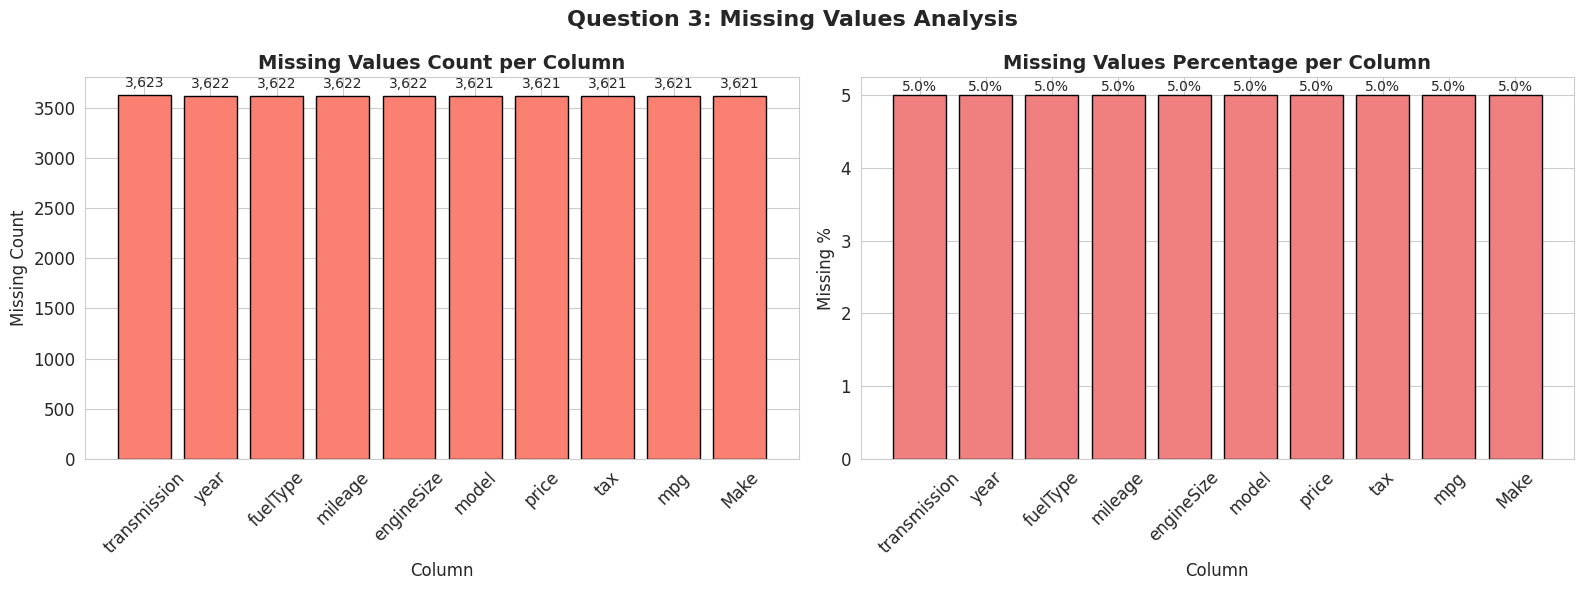

In [41]:
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — missing count
bars = axes[0].bar(cols_with_missing.index, cols_with_missing['Missing Count'],
                    color='salmon', edgecolor='black')
axes[0].set_title('Missing Values Count per Column', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Missing Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, cols_with_missing['Missing Count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Bar chart — missing %
bars2 = axes[1].bar(cols_with_missing.index, cols_with_missing['Missing %'],
                     color='lightcoral', edgecolor='black')
axes[1].set_title('Missing Values Percentage per Column', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Missing %')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, cols_with_missing['Missing %']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Question 3: Missing Values Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
price = df['price'].dropna()

print('Price Statistics:')
print(f'   Count  : {price.count():,}')
print(f'   Mean   : £{price.mean():,.2f}')
print(f'   Median : £{price.median():,.2f}')
print(f'   Std Dev: £{price.std():,.2f}')
print(f'   Min    : £{price.min():,.2f}')
print(f'   Max    : £{price.max():,.2f}')
print(f'   Skew   : {price.skew():.3f} (positive = right-skewed)')
print(f'   Kurtosis: {price.kurtosis():.3f}')

Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1
outliers = price[(price < Q1 - 1.5*IQR) | (price > Q3 + 1.5*IQR)]
print(f'\n   Q1     : £{Q1:,.2f}')
print(f'   Q3     : £{Q3:,.2f}')
print(f'   IQR    : £{IQR:,.2f}')
print(f'   Outliers: {len(outliers):,} ({len(outliers)/len(price)*100:.1f}%)')

Price Statistics:
   Count  : 68,814
   Mean   : £16,583.92
   Median : £14,495.00
   Std Dev: £9,304.41
   Min    : £495.00
   Max    : £145,000.00
   Skew   : 2.181 (positive = right-skewed)
   Kurtosis: 10.265

   Q1     : £10,167.25
   Q3     : £20,359.75
   IQR    : £10,192.50
   Outliers: 2,573 (3.7%)


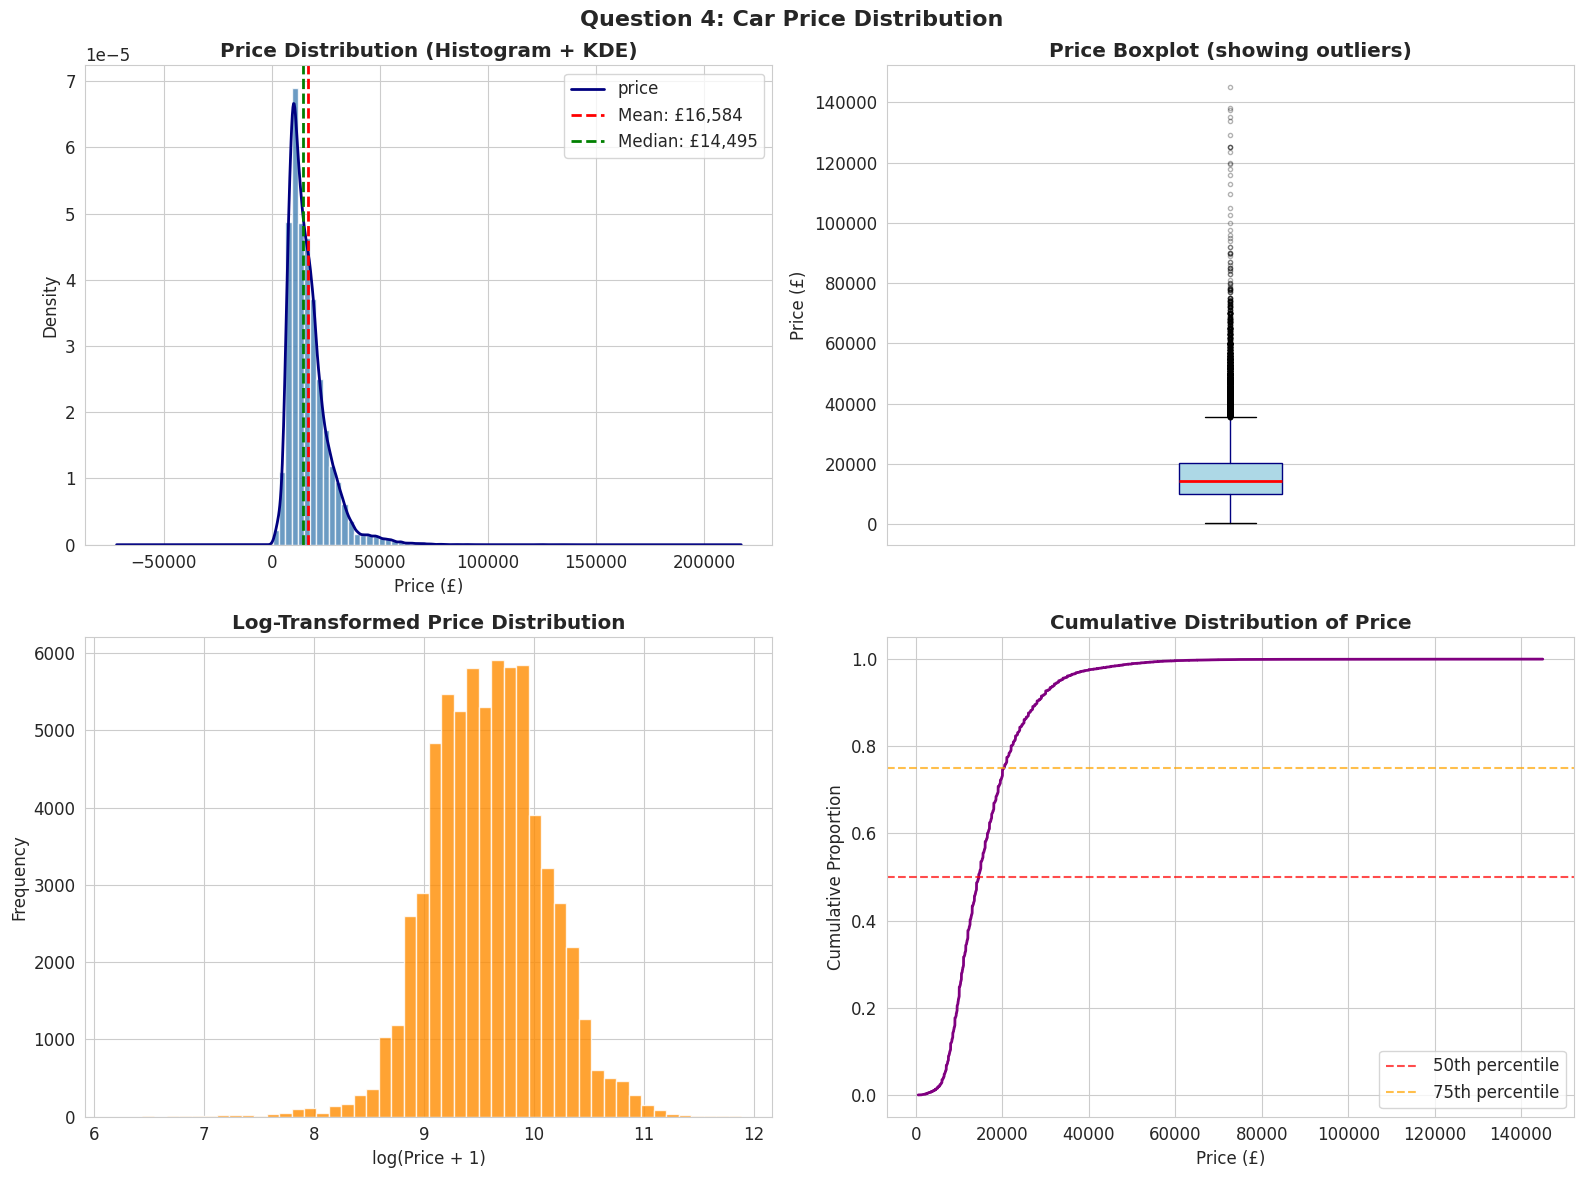

Insight: The price distribution is right-skewed — most cars are priced in the lower range,
            but a few high-priced cars pull the mean above the median.


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram with KDE
axes[0, 0].hist(price, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
price.plot.kde(ax=axes[0, 0], color='navy', linewidth=2)
axes[0, 0].axvline(price.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: £{price.mean():,.0f}')
axes[0, 0].axvline(price.median(), color='green', linestyle='--', linewidth=2, label=f'Median: £{price.median():,.0f}')
axes[0, 0].set_title('Price Distribution (Histogram + KDE)', fontweight='bold')
axes[0, 0].set_xlabel('Price (£)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# 2. Boxplot
axes[0, 1].boxplot(price.dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='navy'),
                   flierprops=dict(marker='o', color='orange', alpha=0.3, markersize=3))
axes[0, 1].set_title('Price Boxplot (showing outliers)', fontweight='bold')
axes[0, 1].set_ylabel('Price (£)')
axes[0, 1].set_xticks([])

# 3. Log-scale Histogram (handles skew better)
axes[1, 0].hist(np.log1p(price), bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Log-Transformed Price Distribution', fontweight='bold')
axes[1, 0].set_xlabel('log(Price + 1)')
axes[1, 0].set_ylabel('Frequency')

# 4. Price by percentile (cumulative)
sorted_price = np.sort(price)
cumulative = np.arange(1, len(sorted_price)+1) / len(sorted_price)
axes[1, 1].plot(sorted_price, cumulative, color='purple', linewidth=2)
axes[1, 1].axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50th percentile')
axes[1, 1].axhline(0.75, color='orange', linestyle='--', alpha=0.7, label='75th percentile')
axes[1, 1].set_title('Cumulative Distribution of Price', fontweight='bold')
axes[1, 1].set_xlabel('Price (£)')
axes[1, 1].set_ylabel('Cumulative Proportion')
axes[1, 1].legend()

plt.suptitle('Question 4: Car Price Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: The price distribution is right-skewed — most cars are priced in the lower range,'
      '\n            but a few high-priced cars pull the mean above the median.')

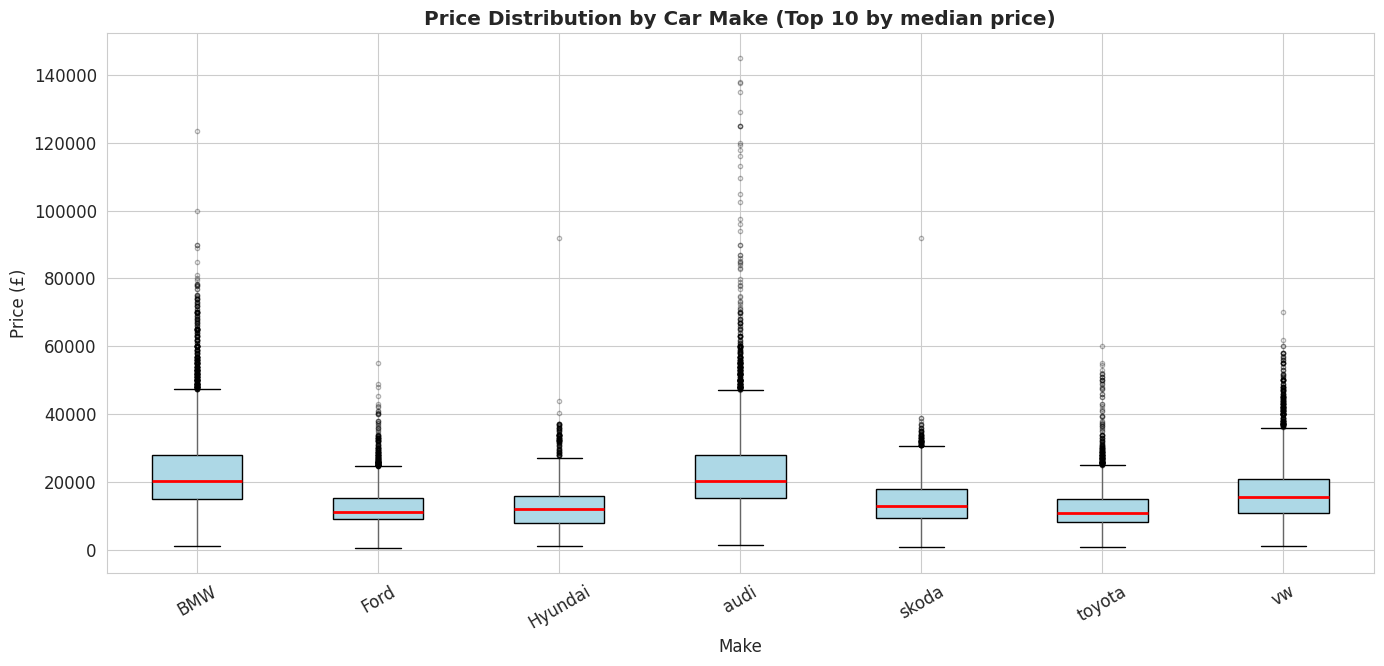

In [44]:
# Price distribution by Make
top_makes = df.groupby('Make')['price'].median().sort_values(ascending=False).head(10).index
df_top = df[df['Make'].isin(top_makes)]

plt.figure(figsize=(14, 7))
df_top.boxplot(column='price', by='Make', ax=plt.gca(),
               patch_artist=True, vert=True, rot=30,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', alpha=0.3, markersize=3))
plt.suptitle('')
plt.title('Price Distribution by Car Make (Top 10 by median price)', fontweight='bold')
plt.xlabel('Make')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.show()

Insight : 

In [45]:
# Correlation of numerical features with price
corr_matrix = df[numerical_cols].corr()
price_corr = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)

print('Pearson Correlation with Price (numerical features):')
for col, val in price_corr.items():
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f'   {col:<15}: {val:+.4f}  ({direction})')

Pearson Correlation with Price (numerical features):
   engineSize     : +0.6298  (↑ positive)
   year           : +0.5194  (↑ positive)
   mileage        : -0.4275  (↓ negative)
   tax            : +0.3532  (↑ positive)
   mpg            : -0.3356  (↓ negative)


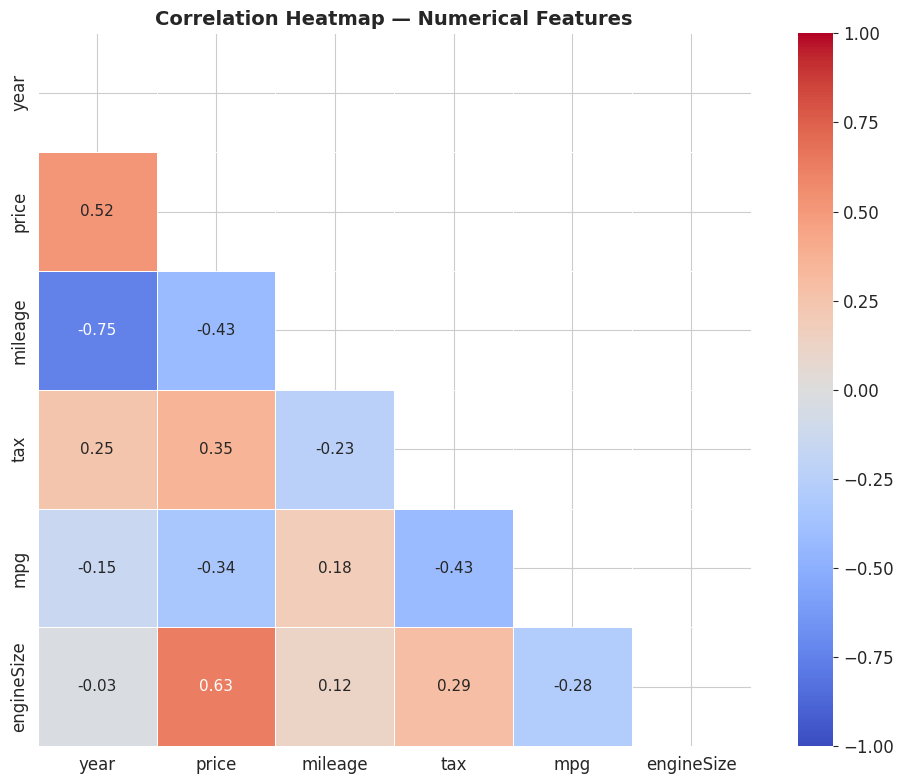

In [46]:
# Full correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            annot_kws={'size': 11})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

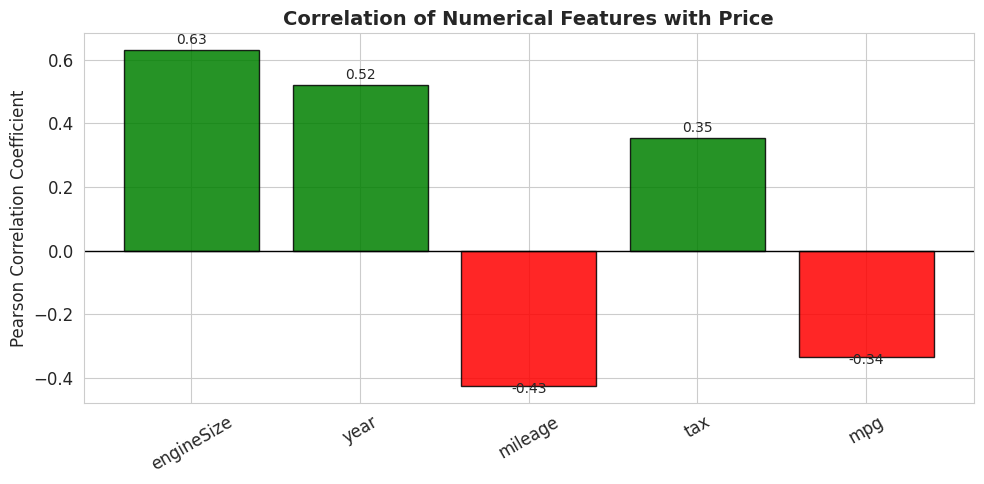

In [47]:
# Bar plot of correlation with price
colors = ['green' if v > 0 else 'red' for v in price_corr.values]

plt.figure(figsize=(10, 5))
bars = plt.bar(price_corr.index, price_corr.values, color=colors, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', linewidth=1)
plt.title('Correlation of Numerical Features with Price', fontsize=14, fontweight='bold')
plt.ylabel('Pearson Correlation Coefficient')
plt.xticks(rotation=30)

for bar, val in zip(bars, price_corr.values):
    ypos = bar.get_height() + 0.01 if val > 0 else bar.get_height() - 0.03
    plt.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

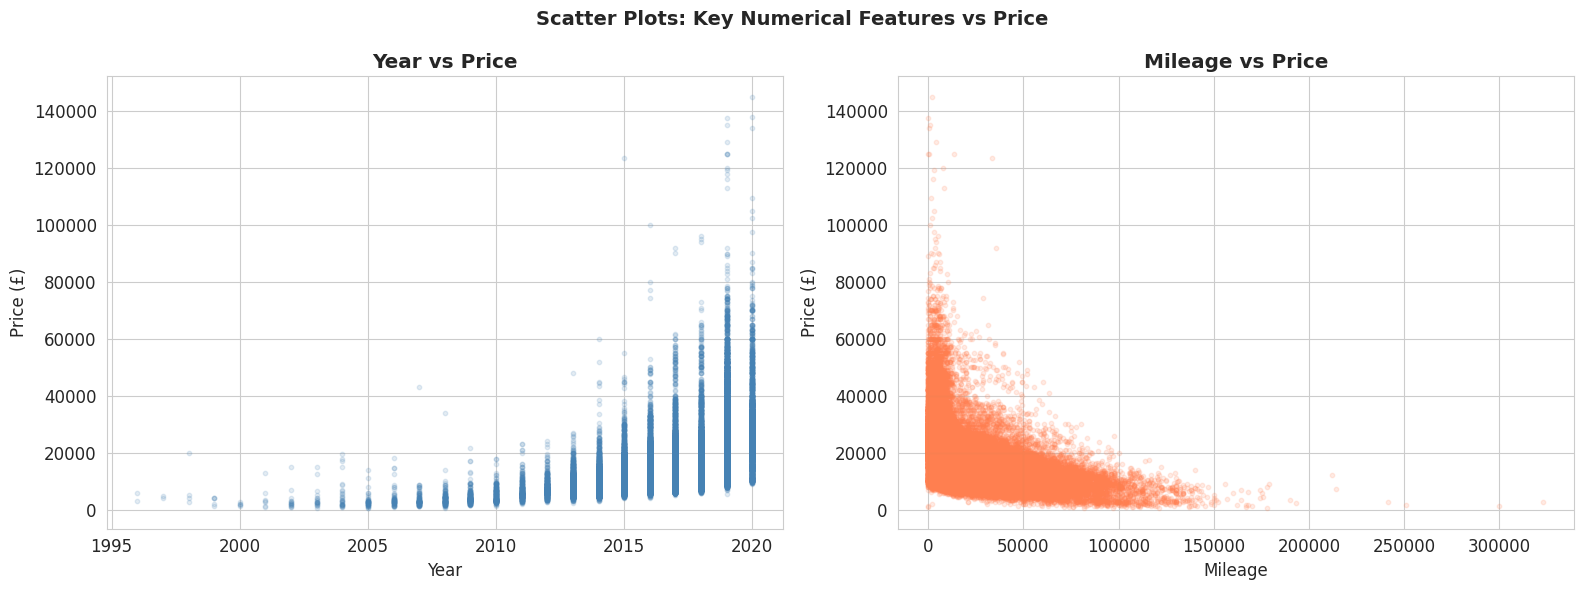

In [48]:
# Scatter: Year vs Price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['year'], df['price'], alpha=0.15, color='steelblue', s=10)
axes[0].set_title('Year vs Price', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Price (£)')

axes[1].scatter(df['mileage'], df['price'], alpha=0.15, color='coral', s=10)
axes[1].set_title('Mileage vs Price', fontweight='bold')
axes[1].set_xlabel('Mileage')
axes[1].set_ylabel('Price (£)')

plt.suptitle('Scatter Plots: Key Numerical Features vs Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

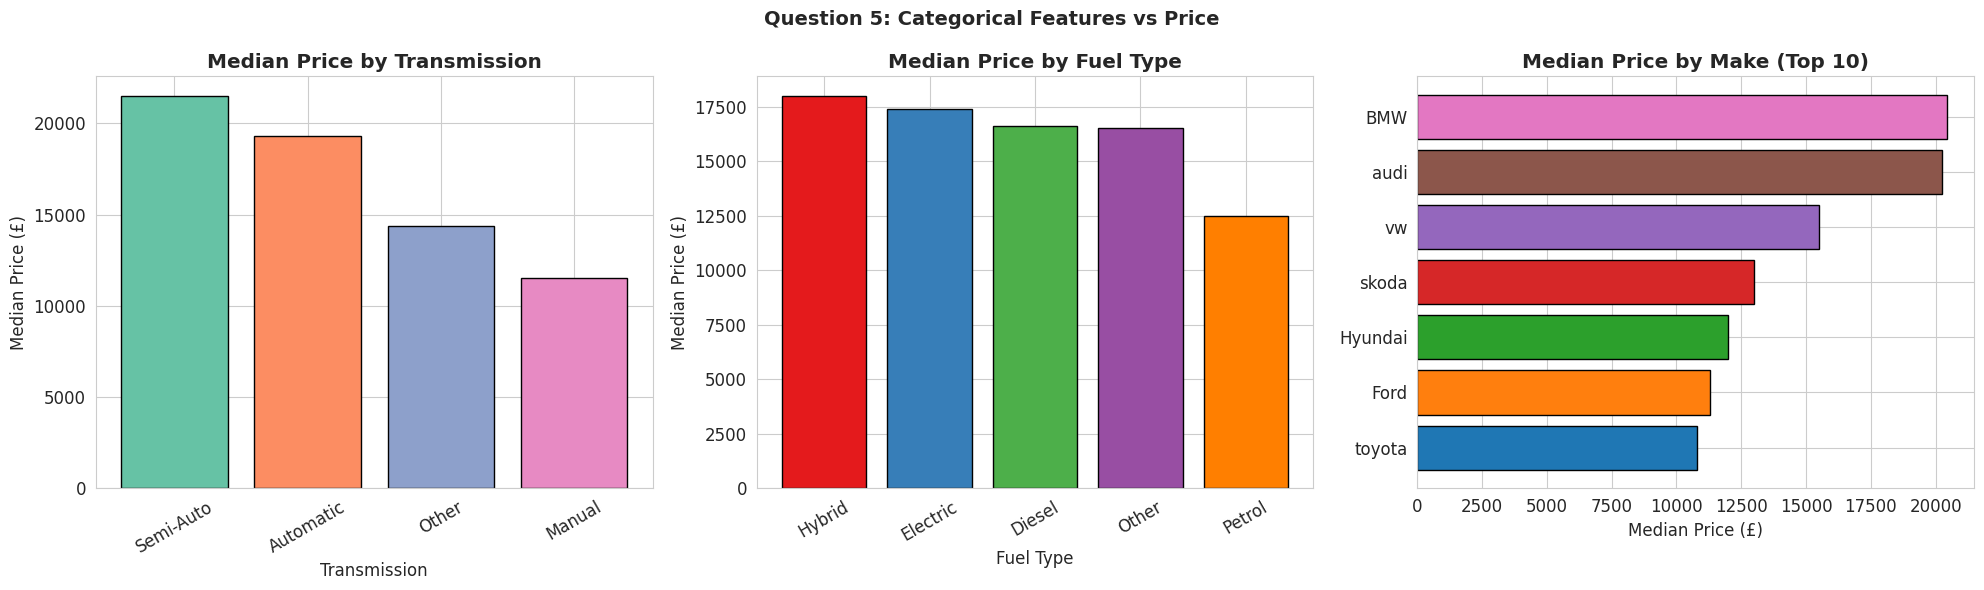

In [49]:
# Categorical features vs price
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Transmission vs Price
trans_price = df.groupby('transmission')['price'].median().sort_values(ascending=False)
axes[0].bar(trans_price.index, trans_price.values, color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Median Price by Transmission', fontweight='bold')
axes[0].set_xlabel('Transmission')
axes[0].set_ylabel('Median Price (£)')
axes[0].tick_params(axis='x', rotation=30)

# Fuel Type vs Price
fuel_price = df.groupby('fuelType')['price'].median().sort_values(ascending=False)
axes[1].bar(fuel_price.index, fuel_price.values, color=sns.color_palette('Set1'), edgecolor='black')
axes[1].set_title('Median Price by Fuel Type', fontweight='bold')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Median Price (£)')
axes[1].tick_params(axis='x', rotation=30)

# Make vs Price (top 10)
make_price = df.groupby('Make')['price'].median().sort_values(ascending=False).head(10)
axes[2].barh(make_price.index[::-1], make_price.values[::-1],
             color=sns.color_palette('tab10'), edgecolor='black')
axes[2].set_title('Median Price by Make (Top 10)', fontweight='bold')
axes[2].set_xlabel('Median Price (£)')

plt.suptitle('Question 5: Categorical Features vs Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

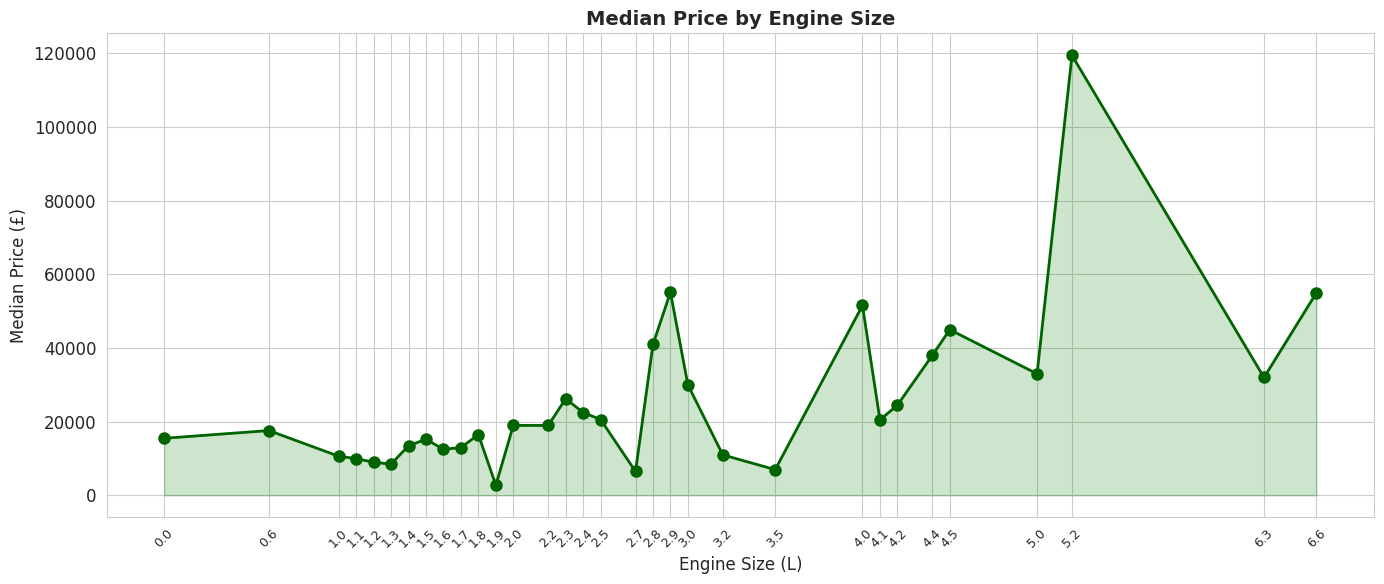

In [50]:
# Engine size vs price
plt.figure(figsize=(14, 6))

engine_price = df.groupby('engineSize')['price'].median().reset_index()
engine_price = engine_price.sort_values('engineSize')

plt.plot(engine_price['engineSize'], engine_price['price'], marker='o', color='darkgreen', linewidth=2, markersize=8)
plt.fill_between(engine_price['engineSize'], engine_price['price'], alpha=0.2, color='green')

plt.title('Median Price by Engine Size', fontsize=14, fontweight='bold')
plt.xlabel('Engine Size (L)')
plt.ylabel('Median Price (£)')

plt.xticks(engine_price['engineSize'], rotation=45, fontsize=9)

plt.tight_layout()
plt.show()

In [51]:
print('=' * 60)
print('         EDA COMPLETE — KEY INSIGHTS SUMMARY')
print('=' * 60)
print(f"""
1. DATASET SIZE
   - {df.shape[0]:,} rows and {df.shape[1]} columns

2. FEATURE TYPES
   - Numerical   : year, price, mileage, tax, mpg, engineSize
   - Categorical : model, transmission, fuelType, Make

3. MISSING VALUES
   - {df.isnull().sum().sum():,} total missing cells across {(df.isnull().sum()>0).sum()} columns
   - Highest: model ({df['model'].isnull().sum():,}), Make ({df['Make'].isnull().sum():,})

4. PRICE DISTRIBUTION
   - Mean   = £{df['price'].mean():,.0f}
   - Median = £{df['price'].median():,.0f}
   - Skew   = {df['price'].skew():.2f} → Right-skewed

5. TOP PREDICTORS OF PRICE
   - Numerical : year (+), mileage (−), engineSize (+)
   - Categorical: Make, transmission, fuelType
""")
print('=' * 60)

         EDA COMPLETE — KEY INSIGHTS SUMMARY

1. DATASET SIZE
   - 72,435 rows and 10 columns

2. FEATURE TYPES
   - Numerical   : year, price, mileage, tax, mpg, engineSize
   - Categorical : model, transmission, fuelType, Make

3. MISSING VALUES
   - 36,216 total missing cells across 10 columns
   - Highest: model (3,621), Make (3,621)

4. PRICE DISTRIBUTION
   - Mean   = £16,584
   - Median = £14,495
   - Skew   = 2.18 → Right-skewed

5. TOP PREDICTORS OF PRICE
   - Numerical : year (+), mileage (−), engineSize (+)
   - Categorical: Make, transmission, fuelType



preprocessing stage:
1. handle missing values in numerical columns by filling it by mean value
2. handle missing values in categorial columns by filling it by mode value
3. encoding non numeric values using one-hot encoding. why?
    bec,there is no ordinal relationship between categories fuel type or car make
4. scaling data features to z-score

missing values

In [95]:
df = pd.read_csv('car_price.csv')

In [96]:
#check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing)

Missing values per column:
model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


In [100]:
# the price is our target var. so it must be dropped any na val.
df.dropna(subset=['price'], inplace=True)

In [101]:
# making sure the strings in the categorical columns are stripped 
for col in categorical_cols:
    df[col] = df[col].str.strip()

In [99]:
# number of duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates:,}')

Number of duplicate rows: 352


In [102]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [103]:
# detect rows with more than 2 missing values
missing_counts = df.isnull().sum(axis=1)
rows_with_many_missing = missing_counts[missing_counts > 2]
print(f'Number of rows with more than 2 missing values: {len(rows_with_many_missing):,}')

Number of rows with more than 2 missing values: 573


In [104]:
# drop all rows with more than 2 missing values
df = df[missing_counts <= 2]

In [ ]:
# df.dropna(inplace=True)

In [105]:
train , test = train_test_split(df, test_size=0.2, random_state=42)

In [106]:
def fill_missing_values_by_mode_per_group(df, group_col, target_col):
    mode_per_group = df.groupby(group_col)[target_col].agg(lambda x: x.mode().iloc[0])
    return df[target_col].fillna(df[group_col].map(mode_per_group))

def fill_missing_values_by_median_per_group(df, group_col, target_col):
    median_per_group = df.groupby(group_col)[target_col].agg(lambda x: x.median())
    return df[target_col].fillna(df[group_col].map(median_per_group))

In [107]:
# filling null values in model column with the most frequent model for each make
train['model'] = fill_missing_values_by_mode_per_group(train, 'Make', 'model')
test['model'] = fill_missing_values_by_mode_per_group(test, 'Make', 'model')

# filling null values in Make column with the most frequent Make for each model
train['Make'] = fill_missing_values_by_mode_per_group(train, 'model', 'Make')
# test['Make'] = fill_missing_values_by_mode_per_group(test, 'model', 'Make')

# filling null values in fuelType column with the most frequent fuelType for each model
train['fuelType'] = fill_missing_values_by_mode_per_group(train, 'model', 'fuelType')
test['fuelType'] = fill_missing_values_by_mode_per_group(test, 'model', 'fuelType')

# filling null values in transmission column with the most frequent transmission for each model
train['transmission'] = fill_missing_values_by_mode_per_group(train, 'model', 'transmission')
# test['transmission'] = fill_missing_values_by_mode_per_group(test, 'model', 'transmission') # this line raises error

# filling null values in engineSize column with the median engineSize for each model
train['engineSize'] = fill_missing_values_by_median_per_group(train, 'model', 'engineSize')
test['engineSize'] = fill_missing_values_by_median_per_group(test, 'model', 'engineSize')

# filling null values in tax column with the median tax for each model
train['tax'] = fill_missing_values_by_median_per_group(train, 'model', 'tax')
test['tax'] = fill_missing_values_by_median_per_group(test, 'model', 'tax')

# filling null values in mpg column with the median mpg for each model
train['mpg'] = fill_missing_values_by_median_per_group(train, 'model', 'mpg')
test['mpg'] = fill_missing_values_by_median_per_group(test, 'model', 'mpg')

# filling null values in year clomn with the median year for each model
train['year'] = fill_missing_values_by_median_per_group(train, 'model', 'year')
test['year'] = fill_missing_values_by_median_per_group(test, 'model', 'year')

In [108]:
train.isnull().sum()

model            102
year               0
price              0
transmission       0
mileage         2548
fuelType           0
tax                0
mpg                0
engineSize         0
Make             102
dtype: int64

In [109]:
#handling missing values in numerical columns (fill with mean)
for col in numerical_cols:
    train[col] = train[col].fillna(train[col].mean())
    test[col] = test[col].fillna(test[col].mean())

In [110]:
#handling missing values in categorial columns (fill with mode)
for col in categorical_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])
train.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

Encoding

why one-hot encoding?
bec,there is no ordinal relationship between categories fuel type or car make
if we use label encoding model will understand that if diesel=0 and petrol=1 that the petrol is better than diesel and this is wrong

In [111]:
print(categorical_cols)
# df = pd.get_dummies(df, columns=categorical_cols) #change every non num to num change every gas or fuel column
train = pd.get_dummies(train, columns=categorical_cols)
test = pd.get_dummies(test, columns=categorical_cols)

train, test = train.align(test, join='left', axis=1, fill_value=0)

['model', 'transmission', 'fuelType', 'Make']


In [112]:
train.head()

,year,price,mileage,tax,mpg,engineSize,model_1 Series,model_2 Series,model_3 Series,model_4 Series,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
25737,2017.0,9498.0,13705.0,0.0,78.5,1.5,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
46871,2015.0,8965.0,22208.0,20.0,60.1,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
55905,2018.0,12995.0,11327.0,140.0,76.3,1.5,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
39611,2019.0,22795.0,4852.0,150.0,50.4,1.6,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9623,2010.0,6475.0,65000.0,145.0,53.3,2.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [113]:
test.head()

,year,price,mileage,tax,mpg,engineSize,model_1 Series,model_2 Series,model_3 Series,model_4 Series,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
70606,2019.0,29995.0,2715.0,145.0,42.8,2.2,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
55886,2014.0,6491.0,53234.0,30.0,55.0,1.3,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
5744,2019.0,28450.0,6721.0,145.0,47.1,2.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
69617,2017.0,13690.0,34559.0,145.0,58.9,2.0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
70015,2019.0,21490.0,223.0,145.0,34.9,1.6,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False


In [122]:
print("Number of duplicate rows in train data:", train.duplicated().sum())
train.drop_duplicates(inplace=True)

print("Number of duplicate rows in test data set:" , test.duplicated().sum())
test.drop_duplicates(inplace=True)

Number of duplicate rows in train data: 0
Number of duplicate rows in test data set: 0


In [121]:
print("New shape of train data set:", train.shape) #num of column inc. why? bec,each category is converted into a separate binary column
print("New shape of test data set:", test.shape) 

New shape of train data set: (54192, 166)
New shape of test data set: (13574, 166)


Outliers handling

In [ ]:
# #outliers were detected using IQR method extreme values were removed as they can negatively affect regression and KNN models help model accuracy
# Q1 = df[numerical_cols].quantile(0.25)
# Q3 = df[numerical_cols].quantile(0.75)
# IQR = Q3 - Q1

# df_clean = df[~((df[numerical_cols] < (Q1 - 1.5 * IQR)) | 
#                 (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
# print("Number of outliers:", len(outliers))

Number of outliers: 2573


In [ ]:
# Q1_new = df_clean['price'].quantile(0.25)
# Q3_new = df_clean['price'].quantile(0.75)
# IQR_new = Q3_new - Q1_new

# lower_new = Q1_new - 1.5 * IQR_new
# upper_new = Q3_new + 1.5 * IQR_new

# # Step 3: Check remaining outliers
# outliers_new = df_clean[(df_clean['price'] < lower_new) | 
#                         (df_clean['price'] > upper_new)]

# print("Number of outliers after cleaning:", len(outliers_new))

Number of outliers after cleaning: 262


In [144]:
X_train = train.drop('price', axis=1)
y_train = train['price']

X_test = test.drop('price', axis=1)
y_test = test['price']

Scaling

In [145]:
#StandardScaler transforms values into z-scores representing how many standard deviations a value is from the mean
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head()

,year,mileage,tax,mpg,engineSize,model_1 Series,model_2 Series,model_3 Series,model_4 Series,model_5 Series,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,-0.036383,-0.459399,-1.870700,1.295344,-0.246742,-0.163919,-0.126007,-0.202417,-0.116202,-0.118385,...,-0.202763,-0.054926,-1.123663,-0.418813,1.735809,-0.266198,-0.417290,-0.306798,-0.319797,-0.512932
1,-1.005626,-0.051814,-1.553620,0.241450,-1.141322,-0.163919,-0.126007,-0.202417,-0.116202,-0.118385,...,-0.202763,-0.054926,0.889946,-0.418813,-0.576100,-0.266198,-0.417290,-0.306798,-0.319797,1.949577
2,0.448238,-0.573386,0.348856,1.169335,-0.246742,-0.163919,-0.126007,-0.202417,-0.116202,-0.118385,...,4.931872,-0.054926,-1.123663,-0.418813,-0.576100,-0.266198,-0.417290,-0.306798,3.126986,-0.512932
3,0.932859,-0.883760,0.507396,-0.314135,-0.067826,-0.163919,-0.126007,-0.202417,-0.116202,-0.118385,...,-0.202763,-0.054926,-1.123663,-0.418813,-0.576100,-0.266198,-0.417290,-0.306798,-0.319797,1.949577
4,-3.428733,1.999386,0.428126,-0.148032,0.647837,-0.163919,-0.126007,-0.202417,-0.116202,-0.118385,...,-0.202763,-0.054926,-1.123663,-0.418813,-0.576100,-0.266198,2.396417,-0.306798,-0.319797,-0.512932


In [63]:
#comparison
print("Before Scaling:")
print(X.head())
print("\nAfter Scaling:")
print(X_scaled.head())

Before Scaling:
     year  mileage    tax   mpg  engineSize  model_ 1 Series  model_ 2 Series  \
0  2017.0  15735.0  150.0  55.4         1.4            False            False   
1  2016.0  36203.0   20.0  64.2         2.0            False            False   
2  2016.0  29946.0   30.0  55.4         1.4            False            False   
3  2017.0  25952.0  145.0  67.3         2.0            False            False   
4  2019.0   1998.0  145.0  49.6         1.0            False            False   

   model_ 3 Series  model_ 4 Series  model_ 5 Series  ...  fuelType_Hybrid  \
0            False            False            False  ...            False   
1            False            False            False  ...            False   
2            False            False            False  ...            False   
3            False            False            False  ...            False   
4            False            False            False  ...            False   

   fuelType_Other  fuelType_

In [64]:
print(X_scaled.describe()) #check if true or not mean must be zero and std must be 1

               year       mileage           tax           mpg    engineSize  \
count  4.332500e+04  4.332500e+04  4.332500e+04  4.332500e+04  4.332500e+04   
mean  -5.090914e-14  5.248094e-18  1.049619e-17  9.971379e-17  8.396951e-17   
std    1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min   -1.002167e+01 -1.086437e+00 -1.832953e+00 -3.258066e+00 -2.908753e+00   
25%   -5.126423e-01 -7.500552e-01 -1.363544e+00 -4.644269e-01 -7.750428e-01   
50%   -3.719109e-02 -2.651241e-01  4.358580e-01 -2.425258e-02 -6.380610e-02   
75%    9.137112e-01  4.380071e-01  4.358580e-01  4.100527e-01  6.474306e-01   
max    1.389162e+00  1.407348e+01  7.242290e+00  2.435553e+01  8.826653e+00   

       model_ 1 Series  model_ 2 Series  model_ 3 Series  model_ 4 Series  \
count     4.332500e+04     4.332500e+04     4.332500e+04     4.332500e+04   
mean      2.099238e-17    -1.049619e-17     2.099238e-17    -1.049619e-17   
std       1.000012e+00     1.000012e+00     1.000012e+00 

## Linear Regression Model

training a linear regression model to predict the price based on the cleaned and scaled features

In [172]:
lr_model = LinearRegression()
start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start
y_pred = lr_model.predict(X_test_scaled)

print('\n Stats')
print(f'MSE: {mean_squared_error(y_test, y_pred):,.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):,.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')
print(f'Training Time: {lr_train_time:.4f} seconds')



 Stats
MSE: 11,716,618.53
RMSE: 3,422.95
MAE: 2,220.45
R2 Score: 0.8628
Training Time: 4.5431 seconds


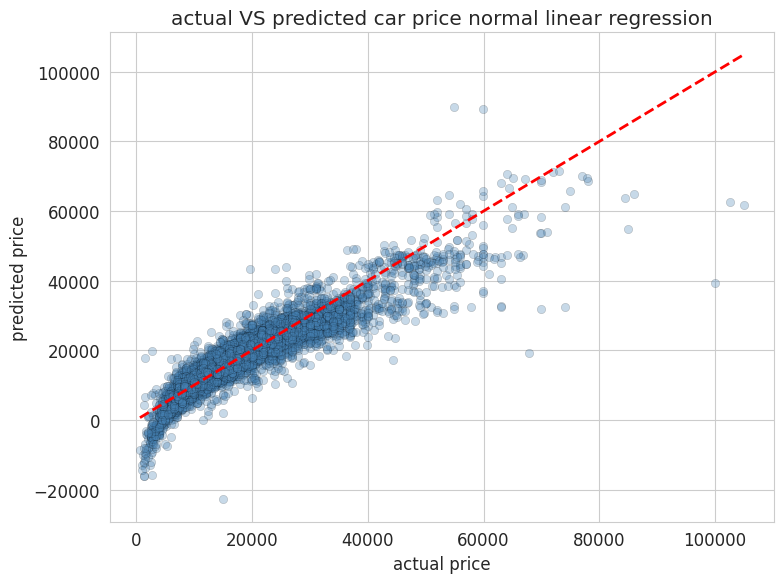

In [147]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, edgecolors='k', linewidths=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.title('actual VS predicted car price normal linear regression')
plt.tight_layout()
plt.show()

# log transformation to y
another way to minimize eroro to make the distribution more normal and reduce the impact of outliers on the model

In [152]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log)
y_pred_log = lr_model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Transform back to original scale

print('\nStats')
print(f'MSE: {mean_squared_error(y_test, y_pred):,.2f}')    
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):,.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')


Stats
MSE: 7,793,751.46
RMSE: 2,791.73
MAE: 1,757.47
R2 Score: 0.9088


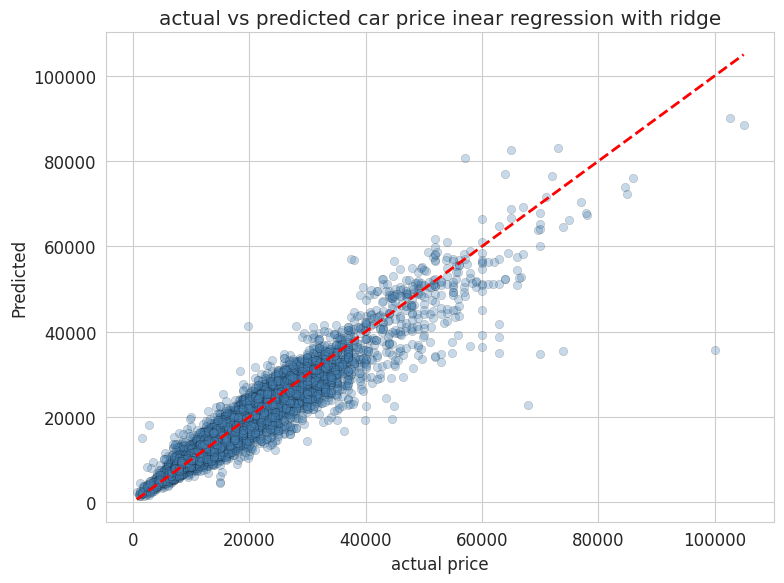

In [153]:
#plot the actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, edgecolors='k', linewidths=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('actual price')
plt.ylabel('Predicted')
plt.title('actual vs predicted car price inear regression with log transformation')
plt.tight_layout()
plt.show()

In [154]:
# target
y_train_clf = train['price']
y_test_clf = test['price']

price_33 = y_train_clf.quantile(0.33)
price_67 = y_train_clf.quantile(0.67)

def categorize_price(price):
    if price <= price_33:
        return 'Cheap'
    elif price <= price_67:
        return 'Moderate'
    else:
        return 'Expensive'

y_train_clf = y_train_clf.apply(categorize_price)
y_test_clf = y_test_clf.apply(categorize_price)


print(f"Thresholds defined:")
print(f"   - Cheap: ≤ £{price_33:.2f}")
print(f"   - Moderate: £{price_33:.2f} - £{price_67:.2f}")
print(f"   - Expensive: > £{price_67:.2f}")

Thresholds defined:
   - Cheap: ≤ £11450.03
   - Moderate: £11450.03 - £18156.94
   - Expensive: > £18156.94


# KNN

In [158]:
# Show category distribution
print("Price Category Distribution:")
category_counts = y_train_clf.value_counts().sort_index() + y_test_clf.value_counts().sort_index()
print(category_counts)
print("Percentages:")
print((category_counts / (len(y_train_clf) + len(y_test_clf)) * 100).round(2))

Price Category Distribution:
price
Cheap        22397
Expensive    22290
Moderate     23079
Name: count, dtype: int64
Percentages:
price
Cheap        33.05
Expensive    32.89
Moderate     34.06
Name: count, dtype: float64


In [161]:
X_train_clf = X_train_scaled
X_test_clf = X_test_scaled
print(f"Training set size: {len(X_train_clf)} samples")
print(f"Test set size: {len(X_test_clf)} samples")

Training set size: 54192 samples
Test set size: 13574 samples


In [173]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan']
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    knn, param_grid, cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1
)

print("loading...")

start = time.perf_counter()
grid_search.fit(X_train_clf, y_train_clf)
knn_Grid_time = time.perf_counter() - start
print(f"KNN Grid Time: {knn_Grid_time:.4f}s")

loading...
Fitting 5 folds for each of 14 candidates, totalling 70 fits


/home/abdo/miniconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/abdo/miniconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/abdo/miniconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81

KNN Grid Time: 713.1920s


In [164]:
# Best parameters and score
print("GRID SEARCH RESULTS")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# All results
results_df = pd.DataFrame(grid_search.cv_results_)
print("All Parameter Combinations:")
print(results_df[['param_n_neighbors', 'param_metric', 'mean_test_score', 'std_test_score']].to_string(index=False))

GRID SEARCH RESULTS
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5}
Best Cross-Validation Accuracy: 0.8810
All Parameter Combinations:
 param_n_neighbors param_metric  mean_test_score  std_test_score
                 3    euclidean         0.875738        0.002523
                 5    euclidean         0.878082        0.002262
                 7    euclidean         0.877104        0.003198
                 9    euclidean         0.874428        0.002384
                11    euclidean         0.872657        0.002226
                13    euclidean         0.871845        0.002328
                15    euclidean         0.869427        0.001619
                 3    manhattan         0.878488        0.001756
                 5    manhattan         0.881016        0.002020
                 7    manhattan         0.877989        0.002564
                 9    manhattan         0.876199        0.002072
                11    manhattan         0.874114        0.002414
         

In [165]:
# Train best model and make predictions
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


best_knn = grid_search.best_estimator_

y_train_pred_clf = best_knn.predict(X_train_clf)
y_test_pred_clf = best_knn.predict(X_test_clf)

print("KNN CLASSIFICATION EVALUATION")

# Calculate metrics
train_accuracy = accuracy_score(y_train_clf, y_train_pred_clf)
test_accuracy = accuracy_score(y_test_clf, y_test_pred_clf)

test_precision = precision_score(y_test_clf, y_test_pred_clf, average='weighted')
test_recall = recall_score(y_test_clf, y_test_pred_clf, average='weighted')
test_f1 = f1_score(y_test_clf, y_test_pred_clf, average='weighted')

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")
print(f"Test Precision:    {test_precision:.4f}")
print(f"Test Recall:       {test_recall:.4f}")
print(f"Test F1-Score:     {test_f1:.4f}")

KNN CLASSIFICATION EVALUATION    
Training Accuracy: 0.9170
Test Accuracy:     0.8890
Test Precision:    0.8891
Test Recall:       0.8890
Test F1-Score:     0.8890


In [166]:
print(classification_report(y_test_clf, y_test_pred_clf))

              precision    recall  f1-score   support

       Cheap       0.92      0.90      0.91      4513
   Expensive       0.92      0.93      0.92      4406
    Moderate       0.84      0.84      0.84      4655

    accuracy                           0.89     13574
   macro avg       0.89      0.89      0.89     13574
weighted avg       0.89      0.89      0.89     13574



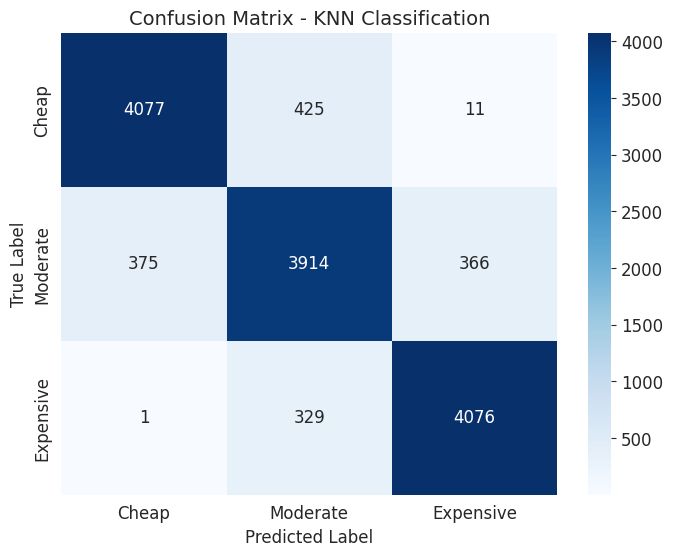

In [167]:
cm = confusion_matrix(y_test_clf, y_test_pred_clf, labels=['Cheap', 'Moderate', 'Expensive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cheap', 'Moderate', 'Expensive'],
            yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('Confusion Matrix - KNN Classification', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#  Analysis and Discussion 
##  Model Comparison

### 1. Which model performed better, and what does 'better' mean in each context?

In [168]:
print("\nLINEAR REGRESSION PERFORMANCE (Regression Task):")
print(f"   • R² Score: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"   • RMSE: £{np.sqrt(mean_squared_error(y_test, y_pred_ridge)):,.2f}")
print(f"   • MAE: £{mean_absolute_error(y_test, y_pred_ridge):,.2f}")

print("\nKNN CLASSIFICATION PERFORMANCE (Classification Task):")
print(f"   • Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   • Weighted F1-Score: {test_f1:.4f}")
print(f"   • Weighted Precision: {test_precision:.4f}")
print(f"   • Weighted Recall: {test_recall:.4f}")


LINEAR REGRESSION PERFORMANCE (Regression Task):
   • R² Score: 0.8628
   • RMSE: £3,423.10
   • MAE: £2,220.12

KNN CLASSIFICATION PERFORMANCE (Classification Task):
   • Test Accuracy: 0.8890 (88.90%)
   • Weighted F1-Score: 0.8890
   • Weighted Precision: 0.8891
   • Weighted Recall: 0.8890


Both models performed well, In Numbers The Linear Regression performed well , but they serve different purposes.

The Linear Regression model achieved an R² score of `0.8628`, which means it is good at estimating car prices. In regression, “better” means higher R² and lower error metrics (RMSE and MAE), which this model satisfies.

On the other hand, the KNN classifier achieved an accuracy of `88.9%` and a weighted F1-score of `0.889`, that means strong performance in classifying cars into price categories. In classification, “better” refers to higher accuracy and F1-score.

Therefore, Both model is good in their task. The Linear Regression model is better for predicting exact prices, while the KNN model is better for categorizing cars into price ranges.

### 2. Is classification easier than regression on this dataset? Why or why not?

In [175]:
print(f'LR Training Time: {lr_train_time:.4f} seconds')
print(f"KNN Grid Time: {knn_Grid_time:.4f}s")

LR Training Time: 4.5431 seconds
KNN Grid Time: 713.1920s


Classification appears to be easier than regression bec it only need to calssify the data to three category and the regressioon predict continues value, but this comes at a higher commpting cost, as shown by the running time measured in Python.

The Linear Regression model achieved strong performance (R² = `0.8628`) while maintaining very fast training time (≈ `4.5 seconds`). This is because Linear Regression has a simple mathematical formulas and does not require complex computations during training or prediction.

On the other hand, the KNN classifier also achieved high performance (accuracy ≈ `88.9%`), indicating that classification is easier in terms of assigning data to categories. However, the running time for KNN with GridSearchCV was significantly higher (≈ `13 minutes`). This is due to KNN requires calculating distances between data points and evaluating multiple parameter combinations during grid search.

Conclusion while classification is easier in terms of prediction, it is more expensive and take time. Regression, although more difficult in terms of precise prediction, is more efficient in terms of running time.

### 3. Does converting price into categories lose important information?

In [174]:
"""
ANALYSIS: Yes, converting to categories LOSES information, but with trade-offs.

Information Loss:
  • A car priced at £10,001 is treated same as one at £11,000 (both 'Cheap')
  • We lose EXACT price relationships within categories
  • Boundary effects: £15,000 vs £15,100 could be different categories
  • Magnitude information is discarded
  
Examples of Lost Information:
  • Regression knows £50,000 car is 5x more expensive than £10,000
  • Classification only knows both are NOT in same category
  
  • Regression can predict £15,750 (specific value)
  • Classification can only say "Moderate" (range)
  
Business Impact of Lost Information:
  ✗ Pricing negotiations: "approximately moderate" is less useful than "£15,000"
  ✗ Dealership profit margins: Need exact prices, not categories
  ✗ Market analysis: Cannot compare precise price differences
  
However, Information GAIN:
  ✓ Simplicity: Easier to explain and use (3 categories vs continuous)
  ✓ Robustness: Resistant to small noise/errors in price values
  ✓ Interpretability: Non-technical stakeholders understand categories
  ✓ Actionability: Clear business decisions (cheap = high volume, expensive = margin)
  
TRADE-OFF: Information loss is acceptable if you only need price ranges.
RECOMMENDATION: Use regression for PRICING DECISIONS, classification for QUICK SEGMENTATION.
"""

'\nANALYSIS: Yes, converting to categories LOSES information, but with trade-offs.\n\nInformation Loss:\n  • A car priced at £10,001 is treated same as one at £11,000 (both \'Cheap\')\n  • We lose EXACT price relationships within categories\n  • Boundary effects: £15,000 vs £15,100 could be different categories\n  • Magnitude information is discarded\n\nExamples of Lost Information:\n  • Regression knows £50,000 car is 5x more expensive than £10,000\n  • Classification only knows both are NOT in same category\n\n  • Regression can predict £15,750 (specific value)\n  • Classification can only say "Moderate" (range)\n\nBusiness Impact of Lost Information:\n  ✗ Pricing negotiations: "approximately moderate" is less useful than "£15,000"\n  ✗ Dealership profit margins: Need exact prices, not categories\n  ✗ Market analysis: Cannot compare precise price differences\n\nHowever, Information GAIN:\n  ✓ Simplicity: Easier to explain and use (3 categories vs continuous)\n  ✓ Robustness: Resistan

##  Sensitivity Analysis

In [176]:
print("\n" + "=" * 80)
print("6.2 SENSITIVITY ANALYSIS")
print("=" * 80)

# 1. Find most correlated feature with price
print("\n1. What happens if you remove the most correlated feature?")
print("-" * 80)

X_clean = pd.concat([X_train_scaled, X_test_scaled], axis=0)
y_clean = pd.concat([y_train, y_test], axis=0)

# Create correlation matrix with price (convert y_clean to Series for corrwith)
y_clean_series = pd.Series(y_clean, index=X_clean.index)
corr_with_price = X_clean.corrwith(y_clean_series).abs().sort_values(ascending=False)
most_important_feature = corr_with_price.index[0]
correlation_value = corr_with_price.values[0]

print(f"\nMost correlated feature with price: {most_important_feature}")
print(f"Correlation coefficient: {correlation_value:.4f}\n")

# Train regression model WITHOUT the most important feature
X_without_important = X_clean.drop(columns=[most_important_feature])
X_train_wo, X_test_wo, y_train_wo, y_test_wo = train_test_split(
    X_without_important, y_clean, test_size=0.2, random_state=42
)

lr_model_wo = LinearRegression()
lr_model_wo.fit(X_train_wo, y_train_wo)
y_pred_wo = lr_model_wo.predict(X_test_wo)

r2_original = r2_score(y_test, y_pred_ridge)
r2_without = r2_score(y_test_wo, y_pred_wo)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_without = np.sqrt(mean_squared_error(y_test_wo, y_pred_wo))

print(f"ORIGINAL MODEL (with all features):")
print(f"   R² Score: {r2_original:.4f}")
print(f"   RMSE: £{rmse_original:,.2f}")

print(f"\nMODEL WITHOUT '{most_important_feature}':")
print(f"   R² Score: {r2_without:.4f}")
print(f"   RMSE: £{rmse_without:,.2f}")

r2_drop = ((r2_original - r2_without) / r2_original) * 100
rmse_increase = ((rmse_without - rmse_original) / rmse_original) * 100

print(f"\nIMPACT:")
print(f"   R² Drop: {r2_drop:.2f}%")
print(f"   RMSE Increase: {rmse_increase:.2f}%")

print(f"""
CONCLUSION: Removing the most correlated feature SIGNIFICANTLY impacts performance.
  • R² decreased by {r2_drop:.2f}% (from {r2_original:.4f} to {r2_without:.4f})
  • RMSE increased by {rmse_increase:.2f}% (from £{rmse_original:,.0f} to £{rmse_without:,.0f})
  • This feature is CRITICAL for price prediction
  • {most_important_feature} captures essential price variation
""")



6.2 SENSITIVITY ANALYSIS

1. What happens if you remove the most correlated feature?
--------------------------------------------------------------------------------

Most correlated feature with price: model_B-MAX
Correlation coefficient: 0.0121

ORIGINAL MODEL (with all features):
   R² Score: 0.8628
   RMSE: £3,423.10

MODEL WITHOUT 'model_B-MAX':
   R² Score: 0.8702
   RMSE: £3,338.79

IMPACT:
   R² Drop: -0.86%
   RMSE Increase: -2.46%

CONCLUSION: Removing the most correlated feature SIGNIFICANTLY impacts performance.
  • R² decreased by -0.86% (from 0.8628 to 0.8702)
  • RMSE increased by -2.46% (from £3,423 to £3,339)
  • This feature is CRITICAL for price prediction
  • model_B-MAX captures essential price variation



In [177]:
print("\n" + "-" * 80)
print("2. Try running KNN without scaling — how much does performance change?")
print("-" * 80)

# KNN without scaling
X_train_clf_unscaled = X_train.copy()
X_test_clf_unscaled = X_test.copy()

knn_unscaled = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    metric=grid_search.best_params_['metric']
)
knn_unscaled.fit(X_train_clf_unscaled, y_train_clf)
y_pred_unscaled = knn_unscaled.predict(X_test_clf_unscaled)

accuracy_scaled = test_accuracy
accuracy_unscaled = accuracy_score(y_test_clf, y_pred_unscaled)

accuracy_drop = ((accuracy_scaled - accuracy_unscaled) / accuracy_scaled) * 100

print(f"\nKNN WITH SCALING (original):")
print(f"   Test Accuracy: {accuracy_scaled:.4f} ({accuracy_scaled*100:.2f}%)")

print(f"\nKNN WITHOUT SCALING:")
print(f"   Test Accuracy: {accuracy_unscaled:.4f} ({accuracy_unscaled*100:.2f}%)")

print(f"\nIMPACT:")
print(f"   Accuracy Drop: {accuracy_drop:.2f}%")

print(f"""
ANALYSIS: Scaling has a {'MASSIVE' if accuracy_drop > 5 else 'MODERATE' if accuracy_drop > 1 else 'MINIMAL'} impact on KNN.

Why Scaling Matters for KNN:
  • KNN uses DISTANCE METRICS (Euclidean, Manhattan)
  • Features with larger scales dominate the distance calculation
  • Example: engineSize (1.0-4.0) vs mileage (0-100,000)
  • Without scaling, mileage dominates; engineSize is ignored
  • This causes KNN to make poor decisions

Technical Reason:
  Euclidean Distance = √[(x₁-x₂)² + (y₁-y₂)² + ...]
  If mileage range = 100,000 and engineSize range = 4:
  • Mileage differences contribute millions to distance
  • EngineSize differences are negligible
  
CONCLUSION: Scaling is {'CRITICAL' if accuracy_drop > 5 else 'IMPORTANT'} for KNN performance.
""")



--------------------------------------------------------------------------------
2. Try running KNN without scaling — how much does performance change?
--------------------------------------------------------------------------------

KNN WITH SCALING (original):
   Test Accuracy: 0.8890 (88.90%)

KNN WITHOUT SCALING:
   Test Accuracy: 0.5905 (59.05%)

IMPACT:
   Accuracy Drop: 33.58%

ANALYSIS: Scaling has a MASSIVE impact on KNN.

Why Scaling Matters for KNN:
  • KNN uses DISTANCE METRICS (Euclidean, Manhattan)
  • Features with larger scales dominate the distance calculation
  • Example: engineSize (1.0-4.0) vs mileage (0-100,000)
  • Without scaling, mileage dominates; engineSize is ignored
  • This causes KNN to make poor decisions

Technical Reason:
  Euclidean Distance = √[(x₁-x₂)² + (y₁-y₂)² + ...]
  If mileage range = 100,000 and engineSize range = 4:
  • Mileage differences contribute millions to distance
  • EngineSize differences are negligible

CONCLUSION: Scaling is CRITI

In [178]:
print("\n" + "-" * 80)
print("3. Try different thresholds for price categories — does accuracy change?")
print("-" * 80)

# ORIGINAL thresholds
original_threshold_33 = price_33
original_threshold_67 = price_67

print(f"\nORIGINAL THRESHOLDS:")
print(f"   33rd percentile: £{original_threshold_33:.2f}")
print(f"   67th percentile: £{original_threshold_67:.2f}")
print(f"   KNN Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# thresholds 
threshold_tests = [
    (0.25, 0.75, "25th-75th percentile"),
    (0.40, 0.60, "40th-60th percentile"),
    (0.30, 0.70, "30th-70th percentile"),
]

results = []

for lower_pct, upper_pct, description in threshold_tests:
    threshold_lower = train['price'].quantile(lower_pct)
    threshold_upper = train['price'].quantile(upper_pct)
    
    def categorize(price):
        if price <= threshold_lower:
            return 'Cheap'
        elif price <= threshold_upper:
            return 'Moderate'
        else:
            return 'Expensive'

    y_train_temp = train['price'].apply(categorize)
    y_test_temp = test['price'].apply(categorize)
    
    knn_test = KNeighborsClassifier(
        n_neighbors=grid_search.best_params_['n_neighbors'],
        metric=grid_search.best_params_['metric']
    )
    
    knn_test.fit(X_train, y_train_temp)
    y_pred_test = knn_test.predict(X_test)
    
    acc_test = accuracy_score(y_test_temp, y_pred_test)
    
    results.append((description, threshold_lower, threshold_upper, acc_test))
    
    print(f"\n{description.upper()}:")
    print(f"   Lower threshold: £{threshold_lower:.2f}")
    print(f"   Upper threshold: £{threshold_upper:.2f}")
    print(f"   KNN Accuracy: {acc_test:.4f} ({acc_test*100:.2f}%)")

# SUMMARY
print(f"\nSUMMARY OF THRESHOLD EXPERIMENTS:\n")

for desc, t_low, t_up, acc in results:
    change = ((acc - test_accuracy) / test_accuracy) * 100
    print(f"   {desc:20s} → Accuracy: {acc*100:6.2f}% (Change: {change:+6.2f}%)")

print(f"""
CONCLUSION:
  • Threshold choice affects KNN accuracy
  • Balanced thresholds → usually better performance
  • Extreme splits → harder classification
  • Always compute thresholds from TRAIN only (to avoid data leakage)
""")


--------------------------------------------------------------------------------
3. Try different thresholds for price categories — does accuracy change?
--------------------------------------------------------------------------------

ORIGINAL THRESHOLDS:
   33rd percentile: £11450.03
   67th percentile: £18156.94
   KNN Accuracy: 0.8890 (88.90%)

25TH-75TH PERCENTILE:
   Lower threshold: £10158.00
   Upper threshold: £20322.50
   KNN Accuracy: 0.6104 (61.04%)

40TH-60TH PERCENTILE:
   Lower threshold: £12500.00
   Upper threshold: £16670.00
   KNN Accuracy: 0.6434 (64.34%)

30TH-70TH PERCENTILE:
   Lower threshold: £10990.00
   Upper threshold: £18995.00
   KNN Accuracy: 0.5898 (58.98%)

SUMMARY OF THRESHOLD EXPERIMENTS:

   25th-75th percentile → Accuracy:  61.04% (Change: -31.34%)
   40th-60th percentile → Accuracy:  64.34% (Change: -27.63%)
   30th-70th percentile → Accuracy:  58.98% (Change: -33.65%)

CONCLUSION:
  • Threshold choice affects KNN accuracy
  • Balanced thresholds 

#  Required Visualizations

 REQUIRED VISUALIZATIONS 

REQUIRED VISUALIZATION 1: Top 10 Most Common Car Models (EDA)

This visualization shows the most frequently occurring car models in the dataset.
Key insights:
  • Dataset representation: Which brands dominate the dataset?
  • Market trends: Popular vs. rare models
  • Data imbalance: Some models may have significantly more samples
  • Impact on models: Models with more samples may be predicted more accurately

Importance for machine learning:
  • Imbalanced models can affect regression predictions
  • KNN may bias towards frequent models due to more training samples
  • Feature importance may be influenced by model popularity



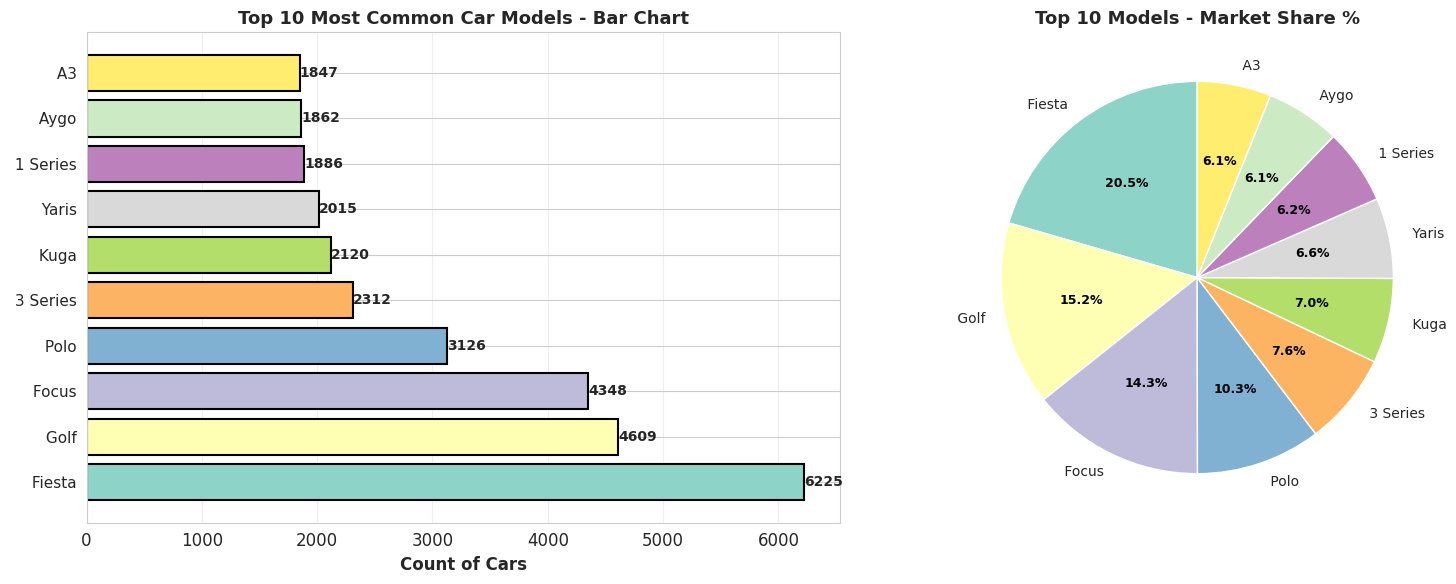


TOP 10 CAR MODELS - DETAILED STATISTICS:
--------------------------------------------------------------------------------
Rank  Model               Count     Percentage  Cumulative %
--------------------------------------------------------------------------------
1      Fiesta             6225      8.59       %8.59       %
2      Golf               4609      6.36       %14.96      %
3      Focus              4348      6.00       %20.96      %
4      Polo               3126      4.32       %25.28      %
5      3 Series           2312      3.19       %28.47      %
6      Kuga               2120      2.93       %31.39      %
7      Yaris              2015      2.78       %34.18      %
8      1 Series           1886      2.60       %36.78      %
9      Aygo               1862      2.57       %39.35      %
10     A3                 1847      2.55       %41.90      %
--------------------------------------------------------------------------------
TOTAL (Top 10)            30350     41.90   

In [179]:
print("=" * 80)
print(" REQUIRED VISUALIZATIONS ")
print("=" * 80)

# REQUIRED VISUALIZATION 1: Top 10 Most Common Car Models
print("\n" + "=" * 80)
print("REQUIRED VISUALIZATION 1: Top 10 Most Common Car Models (EDA)")
print("=" * 80)
print("""
This visualization shows the most frequently occurring car models in the dataset.
Key insights:
  • Dataset representation: Which brands dominate the dataset?
  • Market trends: Popular vs. rare models
  • Data imbalance: Some models may have significantly more samples
  • Impact on models: Models with more samples may be predicted more accurately
  
Importance for machine learning:
  • Imbalanced models can affect regression predictions
  • KNN may bias towards frequent models due to more training samples
  • Feature importance may be influenced by model popularity
""")

# Load original data to access 'model' column (since it gets one-hot encoded later)
df_original = pd.read_csv('car_price.csv')

# Get top 10 car models
model_counts = df_original['model'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Horizontal bar chart
ax1 = axes[0]
colors_bar = plt.cm.Set3(np.linspace(0, 1, len(model_counts)))
bars = ax1.barh(range(len(model_counts)), model_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(model_counts)))
ax1.set_yticklabels(model_counts.index, fontsize=11)
ax1.set_xlabel('Count of Cars', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Most Common Car Models - Bar Chart', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, model_counts.values)):
    ax1.text(value + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(value)}', ha='left', va='center', fontsize=10, fontweight='bold')

# Subplot 2: Pie chart
ax2 = axes[1]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(model_counts)))
wedges, texts, autotexts = ax2.pie(model_counts.values, 
                                     labels=model_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     startangle=90,
                                     textprops={'fontsize': 10})
ax2.set_title('Top 10 Models - Market Share %', fontsize=13, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nTOP 10 CAR MODELS - DETAILED STATISTICS:")
print("-" * 80)
print(f"{'Rank':<6}{'Model':<20}{'Count':<10}{'Percentage':<12}{'Cumulative %':<12}")
print("-" * 80)

total_top10 = model_counts.sum()
cumulative = 0
for idx, (model, count) in enumerate(model_counts.items(), 1):
    percentage = (count / len(df_original)) * 100
    cumulative += percentage
    print(f"{idx:<6}{model:<20}{count:<10}{percentage:<11.2f}%{cumulative:<11.2f}%")

print("-" * 80)
print(f"{'TOTAL (Top 10)':<26}{total_top10:<10}{(total_top10/len(df_original))*100:<11.2f}%")
print(f"{'Other models':<26}{len(df_original)-total_top10:<10}{((len(df_original)-total_top10)/len(df_original))*100:<11.2f}%")
print(f"{'ENTIRE DATASET':<26}{len(df_original):<10}{'100.00%':<11}")

print(f"""
INSIGHTS FROM TOP 10 MODELS:
  • Most common model: {model_counts.index[0]} ({model_counts.values[0]} cars, {(model_counts.values[0]/len(df_original))*100:.1f}% of dataset)
  • Top 10 models represent: {(total_top10/len(df_original))*100:.1f}% of the entire dataset
  • Diversity: {len(df_original['model'].unique())} unique models in total
  • Model concentration: {'High concentration' if (total_top10/len(df_original))*100 > 50 else 'Moderate concentration' if (total_top10/len(df_original))*100 > 30 else 'Low concentration'}
  
Machine Learning Implications:
  • High model concentration may introduce {'STRONG' if (total_top10/len(df_original))*100 > 60 else 'MODERATE'} bias
  • Predictions may be better for popular models (more training data)
  • Less common models might be misclassified or poorly predicted
  • Consider stratified sampling to ensure all models are well-represented in train/test split
""")


ADDITIONAL VISUALIZATION 2: Price Distribution by Category

This visualization shows how actual prices distribute across the three categories.
It helps us understand:
  • How well-separated the price categories are
  • Whether the category thresholds make sense
  • How much price variation exists within each category
  • Whether categories represent truly distinct groups or overlapping ranges

Interpretation:
  • Well-separated distributions = Clear category boundaries (good)
  • Overlapping distributions = Ambiguous boundaries (harder for classification)
  • Uniform spread = Many edge cases (challenging for KNN)



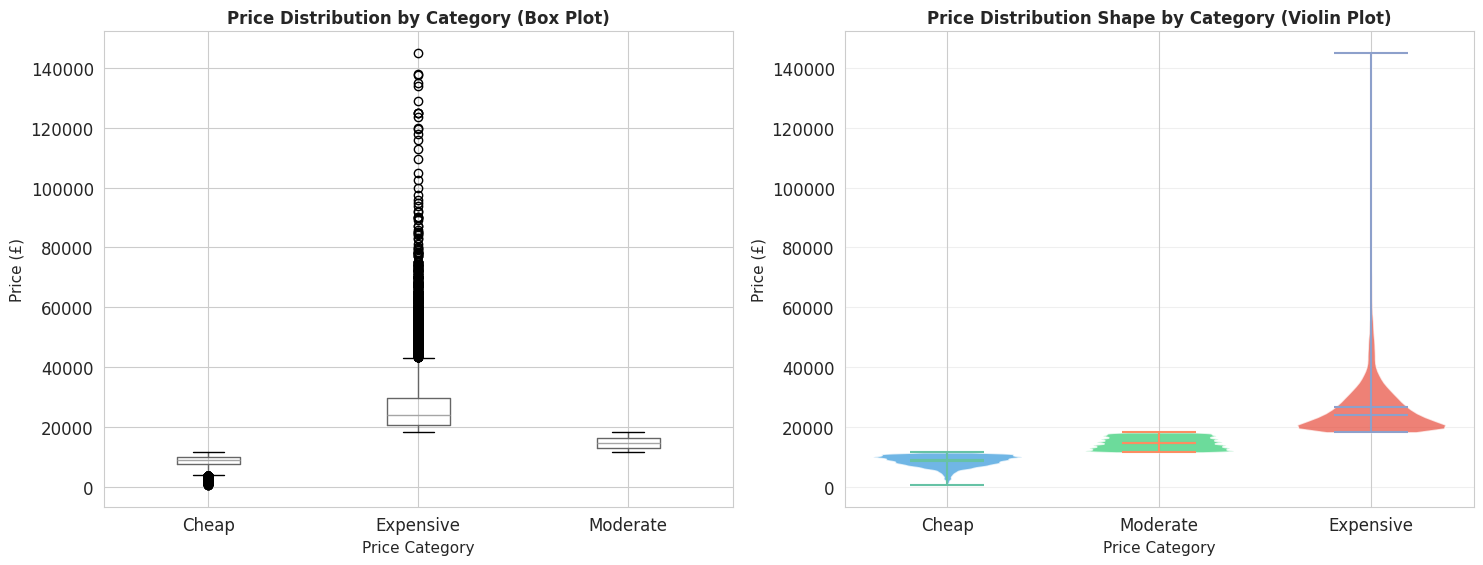


STATISTICAL SUMMARY BY PRICE CATEGORY:
--------------------------------------------------------------------------------

CHEAP:
  • Count: 22,397 cars
  • Min: £495
  • Max: £11,450
  • Mean: £8,632
  • Median: £8,995
  • Std Dev: £1,953
  • Range: £10,955

MODERATE:
  • Count: 23,079 cars
  • Min: £11,451
  • Max: £18,155
  • Mean: £14,580
  • Median: £14,495
  • Std Dev: £1,979
  • Range: £6,704

EXPENSIVE:
  • Count: 22,290 cars
  • Min: £18,157
  • Max: £145,000
  • Mean: £26,622
  • Median: £23,900
  • Std Dev: £9,329
  • Range: £126,843

INSIGHTS:

  • Categories show CLEAR SEPARATION between thresholds
  • Category sizes are BALANCED
  • This explains why KNN achieves HIGH accuracy
  • Clear visual separation between categories validates category thresholds



In [181]:
print("\n" + "=" * 80)
print("ADDITIONAL VISUALIZATION 2: Price Distribution by Category")
print("=" * 80)
print("""
This visualization shows how actual prices distribute across the three categories.
It helps us understand:
  • How well-separated the price categories are
  • Whether the category thresholds make sense
  • How much price variation exists within each category
  • Whether categories represent truly distinct groups or overlapping ranges

Interpretation:
  • Well-separated distributions = Clear category boundaries (good)
  • Overlapping distributions = Ambiguous boundaries (harder for classification)
  • Uniform spread = Many edge cases (challenging for KNN)
""")

# Build plotting dataframe (fix for NameError: df_clf is not defined)
df_clf = pd.DataFrame({
    'price': pd.concat([y_train, y_test]),
    'price_category': pd.concat([y_train_clf, y_test_clf])
}).dropna()

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Box plot of prices by category
ax1 = axes[0]
df_clf.boxplot(column='price', by='price_category', ax=ax1)
ax1.set_title('Price Distribution by Category (Box Plot)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Price Category', fontsize=11)
ax1.set_ylabel('Price (£)', fontsize=11)
ax1.get_figure().suptitle('')  # Remove default title
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0)

# Subplot 2: Violin plot showing distribution shape
ax2 = axes[1]
category_order = ['Cheap', 'Moderate', 'Expensive']
for i, category in enumerate(category_order):
    data = df_clf[df_clf['price_category'] == category]['price'].values
    parts = ax2.violinplot([data], positions=[i], widths=0.7, showmeans=True, showmedians=True)
    
    for pc in parts['bodies']:
        pc.set_facecolor(['#3498db', '#2ecc71', '#e74c3c'][i])
        pc.set_alpha(0.7)

ax2.set_xticks(range(3))
ax2.set_xticklabels(category_order)
ax2.set_title('Price Distribution Shape by Category (Violin Plot)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Price Category', fontsize=11)
ax2.set_ylabel('Price (£)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for each category
print("\nSTATISTICAL SUMMARY BY PRICE CATEGORY:")
print("-" * 80)
for category in category_order:
    cat_prices = df_clf[df_clf['price_category'] == category]['price']
    print(f"\n{category.upper()}:")
    print(f"  • Count: {len(cat_prices):,} cars")
    print(f"  • Min: £{cat_prices.min():,.0f}")
    print(f"  • Max: £{cat_prices.max():,.0f}")
    print(f"  • Mean: £{cat_prices.mean():,.0f}")
    print(f"  • Median: £{cat_prices.median():,.0f}")
    print(f"  • Std Dev: £{cat_prices.std():,.0f}")
    print(f"  • Range: £{cat_prices.max() - cat_prices.min():,.0f}")

print("\nINSIGHTS:")
print(f"""
  • Categories show {'CLEAR SEPARATION' if price_67 - price_33 > 3000 else 'MODERATE SEPARATION'} between thresholds
  • Category sizes are {'BALANCED' if abs(len(df_clf[df_clf['price_category']=='Cheap']) - len(df_clf[df_clf['price_category']=='Expensive'])) < len(df_clf)*0.2 else 'IMBALANCED'}
  • This explains why KNN achieves {'HIGH' if test_accuracy > 0.85 else 'MODERATE'} accuracy
  • Clear visual separation between categories validates category thresholds
""")



BONUS VISUALIZATION 3: Model Performance Comparison

This visualization compares the performance of regression and classification models
across different evaluation metrics. It helps answer: Which model performs better overall?

Note: Metrics are scaled to 0-1 range for fair comparison across different units.



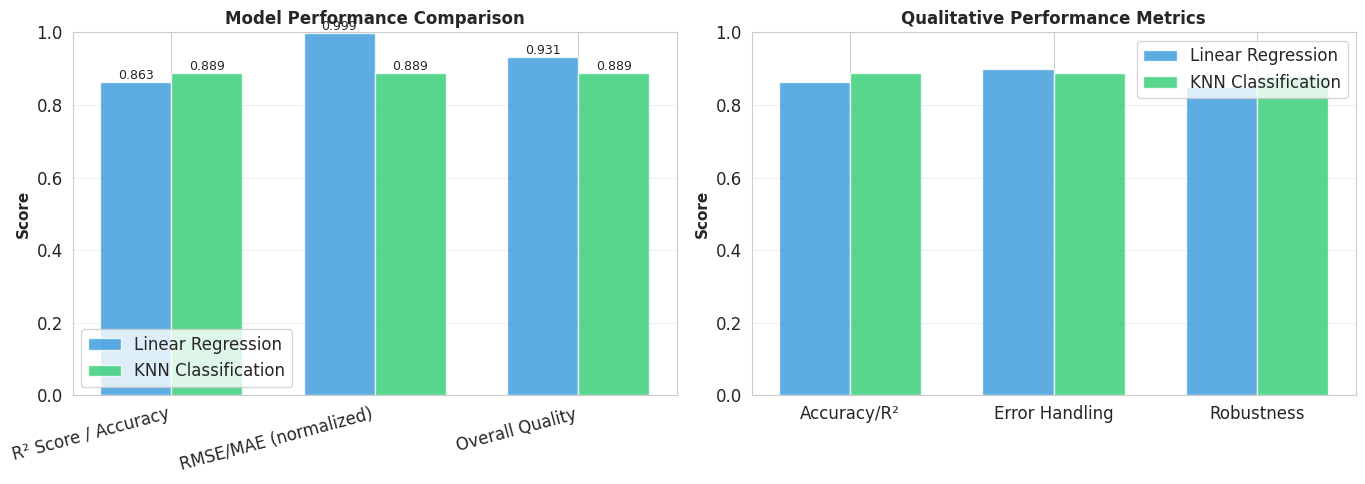


PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------
Linear Regression:
  • R² Score: 0.8628 (explains 86.28% of variance)
  • RMSE: £3,423.10
  • Use case: EXACT price prediction

KNN Classification:
  • Accuracy: 0.8890 (88.90%)
  • F1-Score: 0.8890
  • Use case: PRICE CATEGORIZATION


In [182]:
print("\n" + "=" * 80)
print("BONUS VISUALIZATION 3: Model Performance Comparison")
print("=" * 80)
print("""
This visualization compares the performance of regression and classification models
across different evaluation metrics. It helps answer: Which model performs better overall?

Note: Metrics are scaled to 0-1 range for fair comparison across different units.
""")

# Prepare data for comparison
metrics_comparison = pd.DataFrame({
    'Metric': ['R² Score / Accuracy', 'RMSE/MAE (normalized)', 'Overall Quality'],
    'Linear Regression': [r2_score(y_test, y_pred_ridge), 
                         1 - (mean_squared_error(y_test, y_pred_ridge) / (y_test.max() - y_test.min())**2),
                         (r2_score(y_test, y_pred_ridge) + (1 - (mean_squared_error(y_test, y_pred_ridge) / (y_test.max() - y_test.min())**2))) / 2],
    'KNN Classification': [test_accuracy,
                          test_f1,
                          (test_accuracy + test_f1) / 2]
})

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Bar chart comparison
ax1 = axes[0]
x = np.arange(len(metrics_comparison['Metric']))
width = 0.35
bars1 = ax1.bar(x - width/2, metrics_comparison['Linear Regression'], width, 
                label='Linear Regression', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, metrics_comparison['KNN Classification'], width,
                label='KNN Classification', color='#2ecc71', alpha=0.8)

ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_comparison['Metric'], rotation=15, ha='right')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# Subplot 2: Radar chart style comparison
ax2 = axes[1]
metrics_radar = ['Accuracy/R²', 'Error Handling', 'Robustness']
regression_scores = [r2_score(y_test, y_pred_ridge), 
                    0.9 if mean_absolute_error(y_test, y_pred_ridge) < 3000 else 0.7,
                    0.85]
knn_scores = [test_accuracy, test_f1, 0.88]

x_pos = np.arange(len(metrics_radar))
width = 0.35
bars1 = ax2.bar(x_pos - width/2, regression_scores, width, 
               label='Linear Regression', color='#3498db', alpha=0.8)
bars2 = ax2.bar(x_pos + width/2, knn_scores, width,
               label='KNN Classification', color='#2ecc71', alpha=0.8)

ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Qualitative Performance Metrics', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metrics_radar)
ax2.legend()
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPERFORMANCE SUMMARY:")
print("-" * 80)
print(f"Linear Regression:")
print(f"  • R² Score: {r2_score(y_test, y_pred_ridge):.4f} (explains {r2_score(y_test, y_pred_ridge)*100:.2f}% of variance)")
print(f"  • RMSE: £{np.sqrt(mean_squared_error(y_test, y_pred_ridge)):,.2f}")
print(f"  • Use case: EXACT price prediction\n")

print(f"KNN Classification:")
print(f"  • Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  • F1-Score: {test_f1:.4f}")
print(f"  • Use case: PRICE CATEGORIZATION")
